In [2]:
import pandas as pd

df = pd.read_csv("../Ontrac_data.csv")
df

,Invoice_Date,Client,Products,Amount,Bank_Document
0,9/2/2025,NOVAQUA,SIKACERAM 80I WHITE+GREY,21420.00,TRANSFER RECEIVED
1,9/8/2025,MY DE CONSTRUCTION,REBAR 08 TOR FE 500,11144.00,COLLECTION OF 1 BILL OF EXCHANGE
2,9/17/2025,TERRASTRUCT,CEMENT CPJ35 (21 T +19 bags),36790.00,TRANSFER RECEIVED
3,9/22/2025,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4998.68,OFF-BRANCH CASH DEPOSIT
4,9/23/2025,STE DERRAB LISSAKAN,WOOD TALK LOUVERS 200X1200,4999.60,OFF-BRANCH CASH DEPOSIT
...,...,...,...,...,...
142,8/24/2026,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY,4254.48,OFF-BRANCH CASH DEPOSIT
143,8/24/2026,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY,3999.40,OFF-BRANCH CASH DEPOSIT
144,8/24/2026,AYOUB MARRAKECH,WEBERCOL CLASSIC GREY,3999.40,OFF-BRANCH CASH DEPOSIT
145,8/28/2026,ISMANE DEVELOPPEMENT,WEBERCOL CLASSIC GREY,3916.00,OFF-BRANCH CASH DEPOSIT


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

# Convert data types
df["Invoice_Date"] = pd.to_datetime(df["Invoice_Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# Remove rows where essential fields are missing
df = df.dropna(subset=["Client", "Amount"])

df.head()



,Invoice_Date,Client,Products,Amount,Bank_Document
0,2025-09-02,NOVAQUA,SIKACERAM 80I WHITE+GREY,21420.00,TRANSFER RECEIVED
1,2025-09-08,MY DE CONSTRUCTION,REBAR 08 TOR FE 500,11144.00,COLLECTION OF 1 BILL OF EXCHANGE
2,2025-09-17,TERRASTRUCT,CEMENT CPJ35 (21 T +19 bags),36790.00,TRANSFER RECEIVED
3,2025-09-22,STE DERRAB LISSAKAN,SIKACERAM 80I WHITE + GREY,4998.68,OFF-BRANCH CASH DEPOSIT
4,2025-09-23,STE DERRAB LISSAKAN,WOOD TALK LOUVERS 200X1200,4999.60,OFF-BRANCH CASH DEPOSIT


## 1.Which clients generate the highest total invoice value?

In [4]:
client_total = (
    df.groupby("Client", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

client_total["Amount"] = client_total["Amount"].round(2)

client_total


,Client,Amount
18,NOVAQUA,839480.00
19,SCADACOM MAROC,233610.00
5,ELIPROMO,207435.00
14,MESWANE,180167.00
2,AYOUB MARRAKECH,103042.79
21,STE ARAFIK,101331.04
28,STE RACHIDIA CARREAUX,99000.00
25,STE DERRAB LISSAKAN,94295.24
27,STE OULAD ZAERS PROMO,81675.00
17,NA MEGA S&C,80460.00


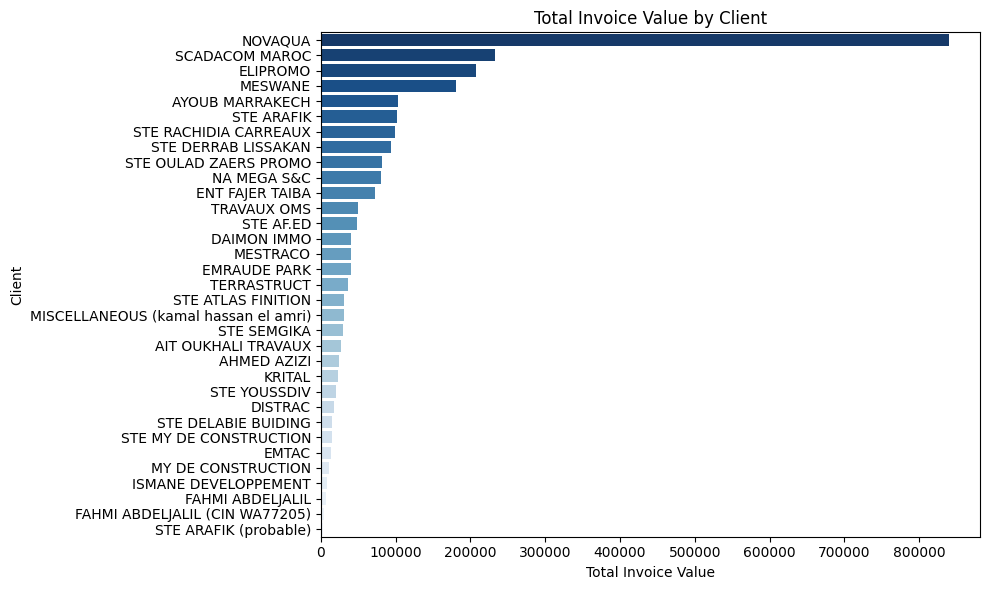

In [5]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=client_total,
    x="Amount",
    y="Client",
    hue="Client",
    legend=False,
    palette="Blues_r"
)

plt.title("Total Invoice Value by Client")
plt.xlabel("Total Invoice Value")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 2.Which clients have the highest average invoice amount?

In [6]:
client_avg = (
    df.groupby("Client", as_index=False)["Amount"]
      .mean()
      .sort_values("Amount", ascending=False)
)

client_avg["Amount"] = client_avg["Amount"].round(2)

client_avg


,Client,Amount
20,STE AF.ED,48500.00
5,ELIPROMO,41487.00
27,STE OULAD ZAERS PROMO,40837.50
3,DAIMON IMMO,40500.00
13,MESTRACO,40230.00
17,NA MEGA S&C,40230.00
6,EMRAUDE PARK,40000.00
19,SCADACOM MAROC,38935.00
18,NOVAQUA,38158.18
31,TERRASTRUCT,36790.00


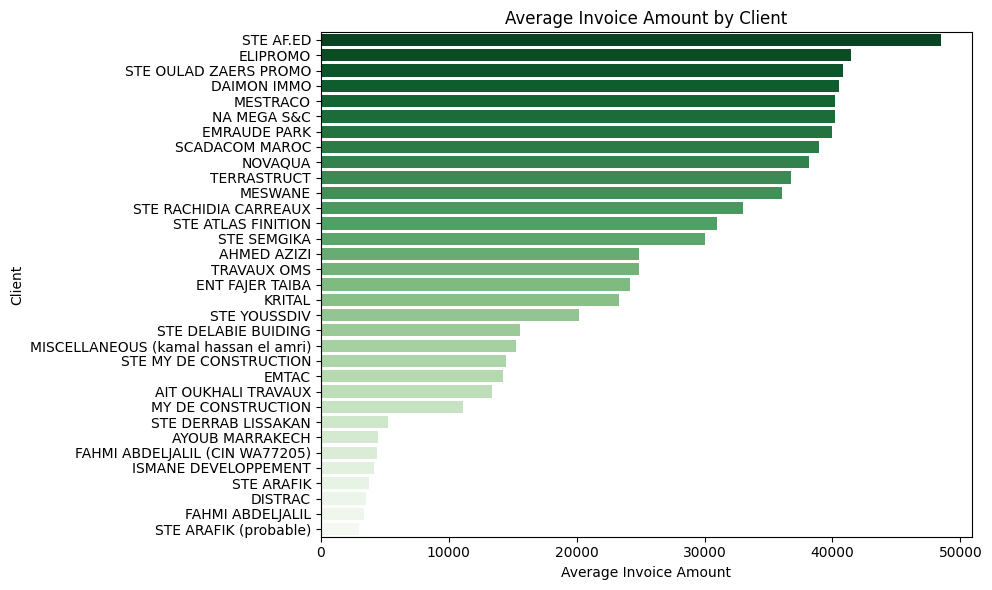

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=client_avg,
    x="Amount",
    y="Client",
    hue="Client",
    legend=False,
    palette="Greens_r"
)

plt.title("Average Invoice Amount by Client")
plt.xlabel("Average Invoice Amount")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 3.Which clients have the most invoices?

In [8]:
client_invoice_count = (
    df.groupby("Client")
      .size()
      .reset_index(name="Invoice_Count")
      .sort_values("Invoice_Count", ascending=False)
)

client_invoice_count


,Client,Invoice_Count
21,STE ARAFIK,27
2,AYOUB MARRAKECH,23
18,NOVAQUA,22
25,STE DERRAB LISSAKAN,18
19,SCADACOM MAROC,6
5,ELIPROMO,5
4,DISTRAC,5
14,MESWANE,5
8,ENT FAJER TAIBA,3
28,STE RACHIDIA CARREAUX,3


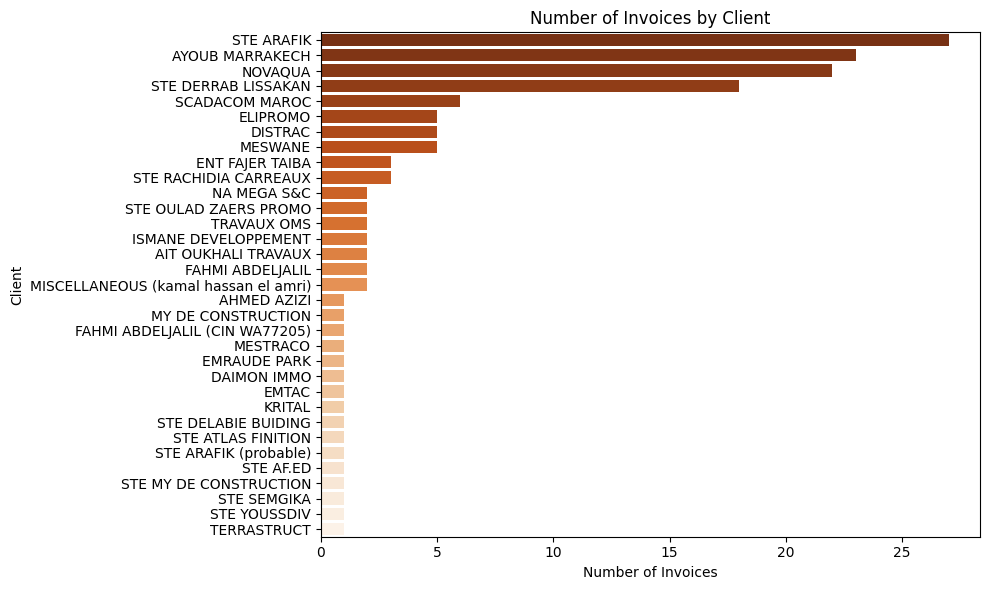

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=client_invoice_count,
    x="Invoice_Count",
    y="Client",
    hue="Client",
    legend=False,
    palette="Oranges_r"
)

plt.title("Number of Invoices by Client")
plt.xlabel("Number of Invoices")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 4.What is the minimum and maximum invoice amount for each client?

In [10]:
client_min_max = (
    df.groupby("Client")["Amount"]
      .agg(
          Min_Invoice="min",
          Max_Invoice="max"
      )
      .reset_index()
)

client_min_max[["Min_Invoice", "Max_Invoice"]] = (
    client_min_max[["Min_Invoice", "Max_Invoice"]].round(2)
)

client_min_max


,Client,Min_Invoice,Max_Invoice
0,AHMED AZIZI,24900.00,24900.00
1,AIT OUKHALI TRAVAUX,10600.00,16160.00
2,AYOUB MARRAKECH,2964.38,4998.71
3,DAIMON IMMO,40500.00,40500.00
4,DISTRAC,2700.00,4110.40
5,ELIPROMO,40230.00,42080.00
6,EMRAUDE PARK,40000.00,40000.00
7,EMTAC,14239.00,14239.00
8,ENT FAJER TAIBA,18330.00,31625.00
9,FAHMI ABDELJALIL,2592.00,4110.40


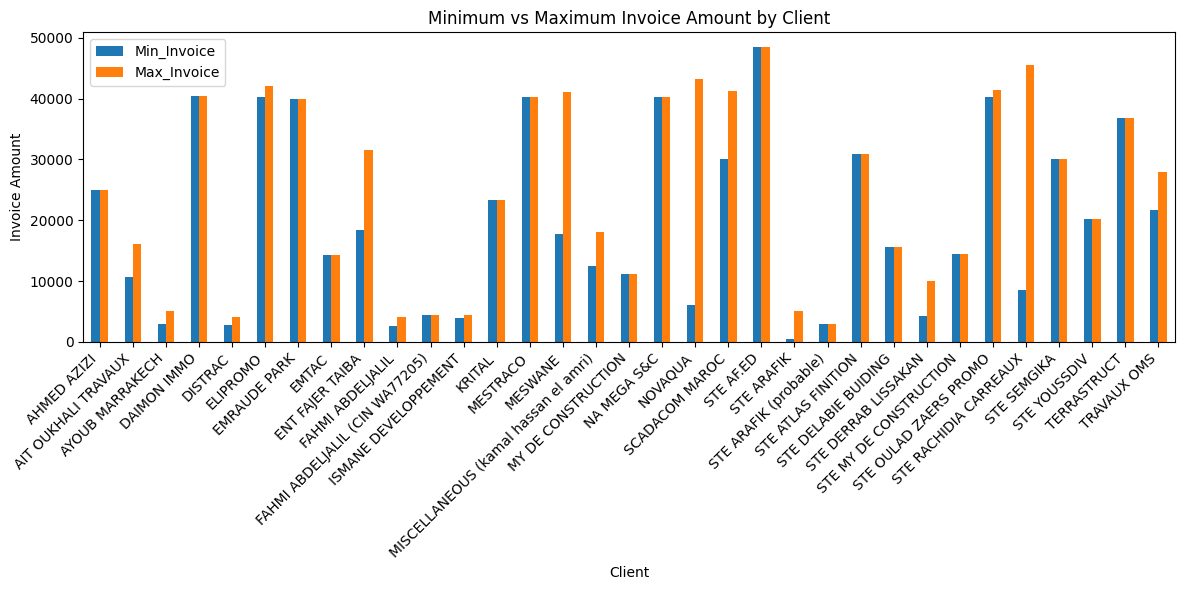

In [11]:
client_min_max.plot(
    x="Client",
    y=["Min_Invoice", "Max_Invoice"],
    kind="bar",
    figsize=(12, 6)
)

plt.title("Minimum vs Maximum Invoice Amount by Client")
plt.xlabel("Client")
plt.ylabel("Invoice Amount")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


## 5.Are high-value invoices concentrated among a small number of clients?

In [12]:
client_contribution = (
    df.groupby("Client", as_index=False)["Amount"]
      .sum()
      .sort_values("Amount", ascending=False)
)

total_revenue = df["Amount"].sum()

client_contribution["Revenue_Percentage"] = (
    client_contribution["Amount"] / total_revenue * 100
).round(2)

client_contribution


,Client,Amount,Revenue_Percentage
18,NOVAQUA,839480.00,31.91
19,SCADACOM MAROC,233610.00,8.88
5,ELIPROMO,207435.00,7.88
14,MESWANE,180167.00,6.85
2,AYOUB MARRAKECH,103042.79,3.92
21,STE ARAFIK,101331.04,3.85
28,STE RACHIDIA CARREAUX,99000.00,3.76
25,STE DERRAB LISSAKAN,94295.24,3.58
27,STE OULAD ZAERS PROMO,81675.00,3.10
17,NA MEGA S&C,80460.00,3.06


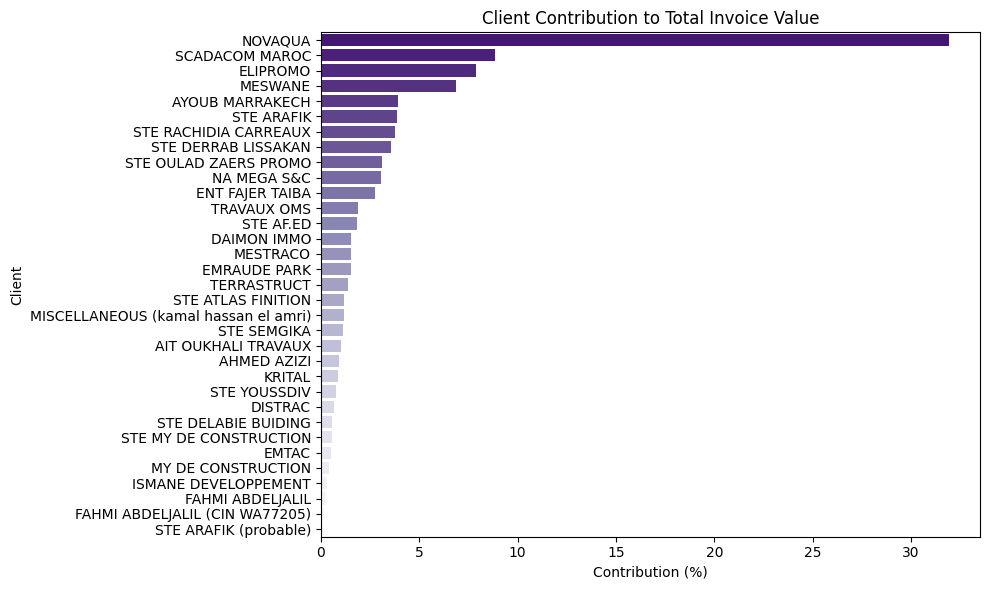

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=client_contribution,
    x="Revenue_Percentage",
    y="Client",
    hue="Client",
    legend=False,
    palette="Purples_r"
)

plt.title("Client Contribution to Total Invoice Value")
plt.xlabel("Contribution (%)")
plt.ylabel("Client")

plt.tight_layout()
plt.show()


## 6.Which clients contribute the largest percentage of total revenue?

In [14]:
client_revenue_share = (
    df.groupby("Client", as_index=False)["Amount"]
      .sum()
      .rename(columns={"Amount": "Total_Revenue"})
)

client_revenue_share["Revenue_Share_%"] = (
    client_revenue_share["Total_Revenue"]
    / client_revenue_share["Total_Revenue"].sum()
    * 100
).round(2)

client_revenue_share = client_revenue_share.sort_values(
    "Revenue_Share_%",
    ascending=False
)

client_revenue_share


,Client,Total_Revenue,Revenue_Share_%
18,NOVAQUA,839480.00,31.91
19,SCADACOM MAROC,233610.00,8.88
5,ELIPROMO,207435.00,7.88
14,MESWANE,180167.00,6.85
2,AYOUB MARRAKECH,103042.79,3.92
21,STE ARAFIK,101331.04,3.85
28,STE RACHIDIA CARREAUX,99000.00,3.76
25,STE DERRAB LISSAKAN,94295.24,3.58
27,STE OULAD ZAERS PROMO,81675.00,3.10
17,NA MEGA S&C,80460.00,3.06


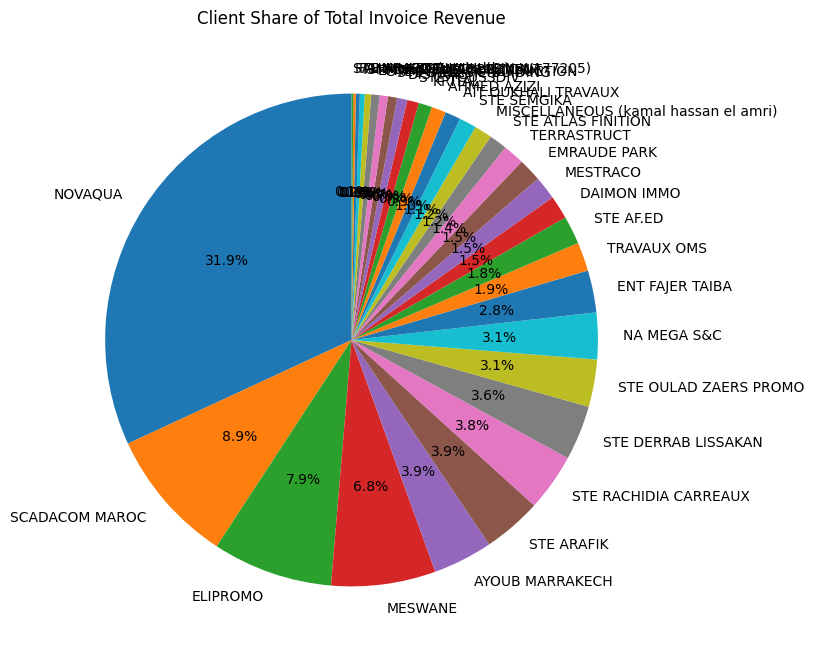

In [15]:
plt.figure(figsize=(8, 8))

plt.pie(
    client_revenue_share["Total_Revenue"],
    labels=client_revenue_share["Client"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Client Share of Total Invoice Revenue")
plt.show()


## 7.Do repeat clients have higher average transaction values?

In [25]:
client_frequency = (
    df.groupby("Client")
      .size()
      .reset_index(name="Invoice_Count")
)

# Merge invoice count back into original data
df_analysis = df.merge(
    client_frequency,
    on="Client",
    how="left"
)

# Classify customers
df_analysis["Client_Type"] = df_analysis["Invoice_Count"].apply(
    lambda x: "Repeat Client" if x > 1 else "One-Time Client"
)

print(df_analysis[
    ["Client", "Amount", "Invoice_Count", "Client_Type"]
])


                   Client    Amount  Invoice_Count      Client_Type
0                 NOVAQUA  21420.00             22    Repeat Client
1      MY DE CONSTRUCTION  11144.00              1  One-Time Client
2             TERRASTRUCT  36790.00              1  One-Time Client
3     STE DERRAB LISSAKAN   4998.68             18    Repeat Client
4     STE DERRAB LISSAKAN   4999.60             18    Repeat Client
..                    ...       ...            ...              ...
142       AYOUB MARRAKECH   4254.48             23    Repeat Client
143       AYOUB MARRAKECH   3999.40             23    Repeat Client
144       AYOUB MARRAKECH   3999.40             23    Repeat Client
145  ISMANE DEVELOPPEMENT   3916.00              2    Repeat Client
146  ISMANE DEVELOPPEMENT   4428.00              2    Repeat Client

[147 rows x 4 columns]


In [26]:
repeat_analysis = (
    df_analysis.groupby("Client_Type", as_index=False)["Amount"]
               .agg(
                   Average_Transaction_Value="mean",
                   Total_Transactions="count",
                   Total_Revenue="sum"
               )
)

repeat_analysis[
    ["Average_Transaction_Value", "Total_Revenue"]
] = repeat_analysis[
    ["Average_Transaction_Value", "Total_Revenue"]
].round(2)

print(repeat_analysis)


       Client_Type  Average_Transaction_Value  Total_Transactions  \
0  One-Time Client                   24892.51                  16   
1    Repeat Client                   17044.29                 131   

   Total_Revenue  
0      398280.21  
1     2232801.67  


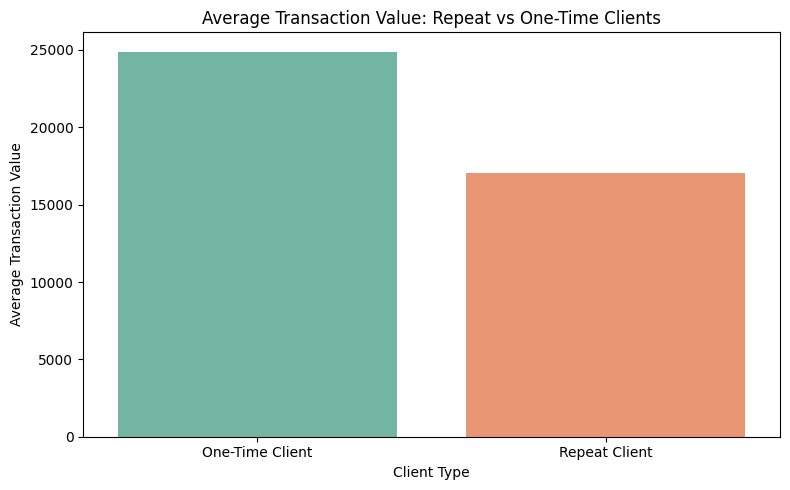

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=repeat_analysis,
    x="Client_Type",
    y="Average_Transaction_Value",
    hue="Client_Type",
    legend=False,
    palette="Set2"
)

plt.title("Average Transaction Value: Repeat vs One-Time Clients")
plt.xlabel("Client Type")
plt.ylabel("Average Transaction Value")

plt.tight_layout()
plt.show()


In [28]:
client_summary = (
    df.groupby("Client")
      .agg(
          Total_Invoice_Value=("Amount", "sum"),
          Average_Invoice_Value=("Amount", "mean"),
          Invoice_Count=("Amount", "count"),
          Minimum_Invoice=("Amount", "min"),
          Maximum_Invoice=("Amount", "max")
      )
      .reset_index()
)

client_summary["Revenue_Share_%"] = (
    client_summary["Total_Invoice_Value"]
    / client_summary["Total_Invoice_Value"].sum()
    * 100
)

client_summary["Customer_Type"] = client_summary["Invoice_Count"].apply(
    lambda x: "Repeat Client" if x > 1 else "One-Time Client"
)

client_summary = client_summary.sort_values(
    "Total_Invoice_Value",
    ascending=False
)

client_summary = client_summary.round(2)

client_summary


,Client,Total_Invoice_Value,Average_Invoice_Value,Invoice_Count,Minimum_Invoice,Maximum_Invoice,Revenue_Share_%,Customer_Type
18,NOVAQUA,839480.00,38158.18,22,6000.00,43210.00,31.91,Repeat Client
19,SCADACOM MAROC,233610.00,38935.00,6,30000.00,41310.00,8.88,Repeat Client
5,ELIPROMO,207435.00,41487.00,5,40230.00,42080.00,7.88,Repeat Client
14,MESWANE,180167.00,36033.40,5,17742.00,41040.00,6.85,Repeat Client
2,AYOUB MARRAKECH,103042.79,4480.12,23,2964.38,4998.71,3.92,Repeat Client
21,STE ARAFIK,101331.04,3753.00,27,384.00,4999.80,3.85,Repeat Client
28,STE RACHIDIA CARREAUX,99000.00,33000.00,3,8600.00,45600.00,3.76,Repeat Client
25,STE DERRAB LISSAKAN,94295.24,5238.62,18,4305.68,10000.00,3.58,Repeat Client
27,STE OULAD ZAERS PROMO,81675.00,40837.50,2,40230.00,41445.00,3.10,Repeat Client
17,NA MEGA S&C,80460.00,40230.00,2,40230.00,40230.00,3.06,Repeat Client


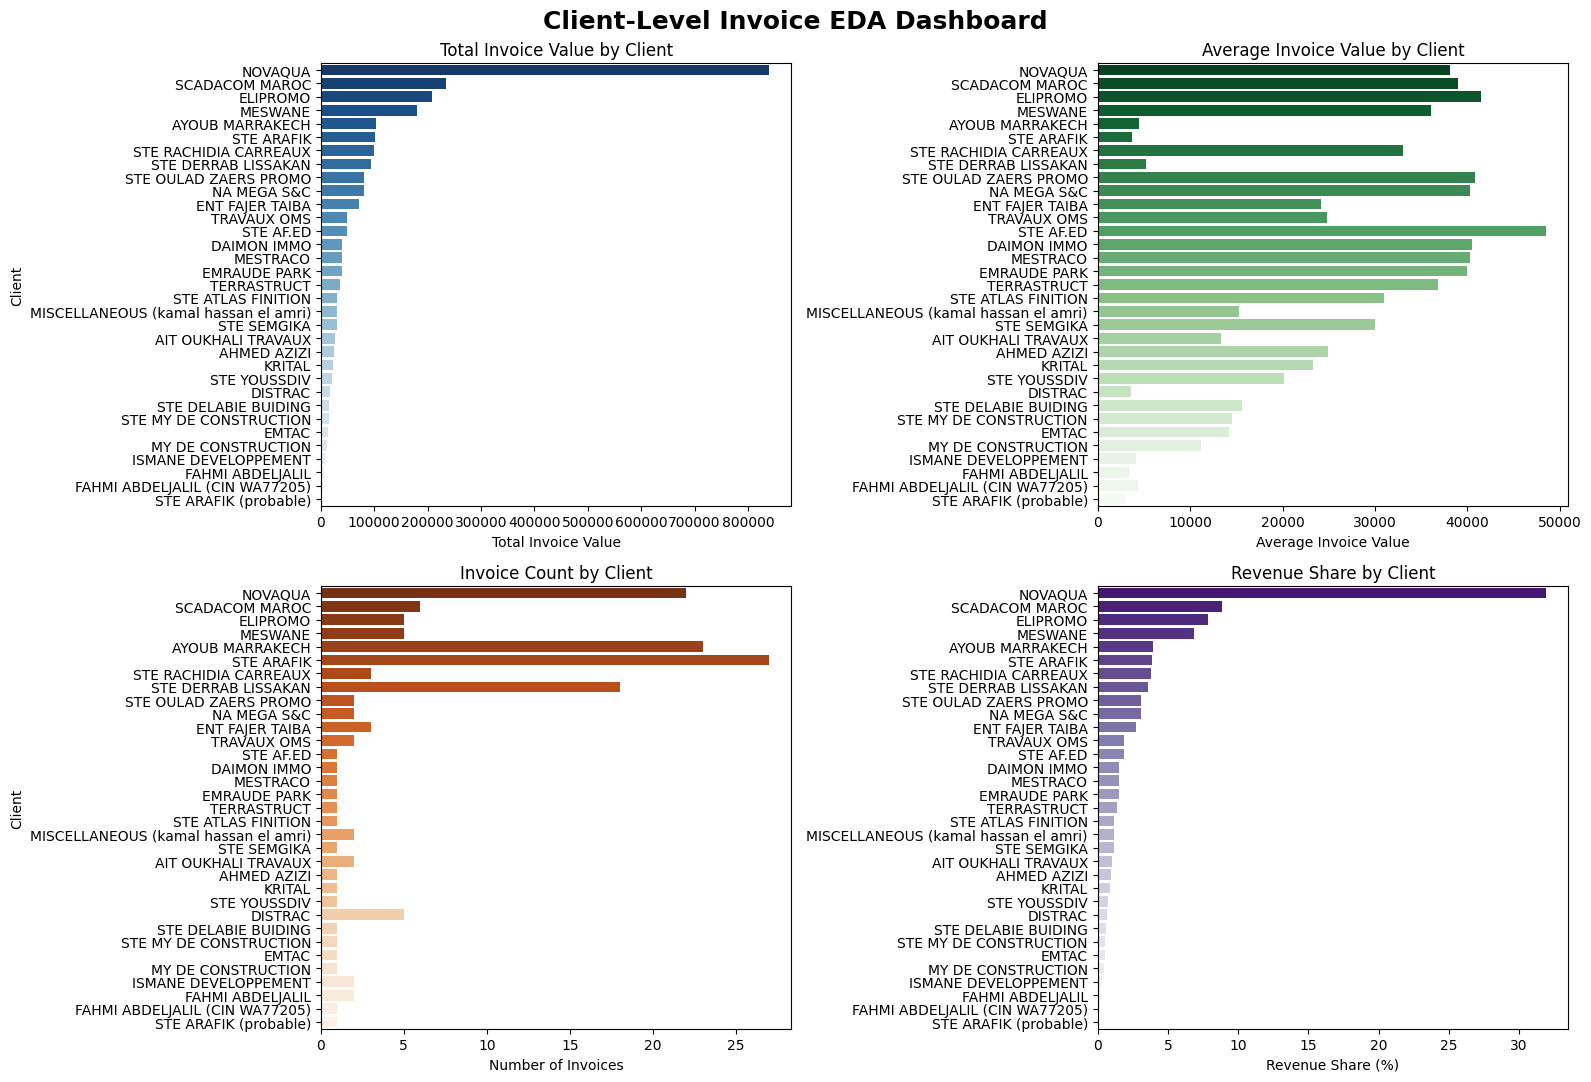

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Total invoice value
sns.barplot(
    data=client_summary,
    x="Total_Invoice_Value",
    y="Client",
    hue="Client",
    legend=False,
    ax=axes[0, 0],
    palette="Blues_r"
)
axes[0, 0].set_title("Total Invoice Value by Client")
axes[0, 0].set_xlabel("Total Invoice Value")
axes[0, 0].set_ylabel("Client")

# 2. Average invoice value
sns.barplot(
    data=client_summary,
    x="Average_Invoice_Value",
    y="Client",
    hue="Client",
    legend=False,
    ax=axes[0, 1],
    palette="Greens_r"
)
axes[0, 1].set_title("Average Invoice Value by Client")
axes[0, 1].set_xlabel("Average Invoice Value")
axes[0, 1].set_ylabel("")

# 3. Invoice count
sns.barplot(
    data=client_summary,
    x="Invoice_Count",
    y="Client",
    hue="Client",
    legend=False,
    ax=axes[1, 0],
    palette="Oranges_r"
)
axes[1, 0].set_title("Invoice Count by Client")
axes[1, 0].set_xlabel("Number of Invoices")
axes[1, 0].set_ylabel("Client")

# 4. Revenue share
sns.barplot(
    data=client_summary,
    x="Revenue_Share_%",
    y="Client",
    hue="Client",
    legend=False,
    ax=axes[1, 1],
    palette="Purples_r"
)
axes[1, 1].set_title("Revenue Share by Client")
axes[1, 1].set_xlabel("Revenue Share (%)")
axes[1, 1].set_ylabel("")

plt.suptitle(
    "Client-Level Invoice EDA Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
